# MUFASA — Colab real-data FULL-FT loss smoke test

This notebook is a **pipeline canary**, not a real training run.

It uses the same real MUFASA JSON corpus / cached SFT rows and the same contextual prompt structure as the main full-fine-tuning workflow, but intentionally overfits a tiny subset so you can verify that:

1. the real corpus can be discovered and parsed;
2. the existing paper-level TRAIN / VALIDATION split is respected;
3. the private TEST split is never parsed;
4. `LiquidAI/LFM2.5-1.2B-Thinking` loads in full-finetuning mode;
5. response-only supervision produces non-empty labels;
6. forward + backward + optimizer steps work;
7. training loss moves in the right direction.

### Smoke workload
- **12 actual TRAIN rows**
- **6 actual VALIDATION rows**
- balanced factual/reasoning where possible
- shortest real contextual examples that fit the smoke context ceiling
- **30 optimizer steps**
- batch size 1
- gradient accumulation 1
- eval every 10 steps
- no checkpoint saving
- no DPO
- no GGUF
- no Kaggle
- no private-test read

A tiny run can overfit by design. A falling training loss proves that the optimization pipeline is alive; it does **not** estimate final model quality.


In [1]:
#@title 1. Install training dependencies
%pip install -q -U unsloth unsloth_zoo "transformers>=5.2.0" datasets trl peft accelerate bitsandbytes sentencepiece pandas pyarrow matplotlib
print("Install complete. If Colab asks for a runtime restart, restart once and continue from Cell 2.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.3/76.3 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.

In [2]:
#@title 2. Check Colab GPU
import os,platform,random,json,re,html,hashlib,gc,inspect,math
from pathlib import Path
from collections import Counter
import numpy as np,pandas as pd,torch

assert torch.cuda.is_available(),"Enable a GPU runtime: Runtime -> Change runtime type -> GPU."
gpu=torch.cuda.get_device_properties(0)
VRAM_GB=gpu.total_memory/1024**3
print("Python:",platform.python_version())
print("PyTorch:",torch.__version__)
print("GPU:",gpu.name)
print("VRAM:",round(VRAM_GB,2),"GiB")
print("BF16:",torch.cuda.is_bf16_supported())

if VRAM_GB>=35:
    SMOKE_MAX_SEQ_LENGTH=2048
elif VRAM_GB>=20:
    SMOKE_MAX_SEQ_LENGTH=1024
else:
    raise RuntimeError("This is a FULL-finetune smoke test. Use an L4/A100/H100-class Colab GPU (>=20 GiB) rather than T4 16 GiB.")
print("Smoke context ceiling:",SMOKE_MAX_SEQ_LENGTH)

Python: 3.13.15
PyTorch: 2.11.0+cu128
GPU: NVIDIA A100-SXM4-40GB
VRAM: 39.49 GiB
BF16: True
Smoke context ceiling: 2048


In [3]:
#@title 3. Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
#@title 4. Smoke configuration
JSON_DIR="/content/drive/MyDrive/ADTC/data"
SPLIT_MANIFEST_PATH="/content/drive/MyDrive/ADTC/data/mufasa_paper_split_manifest.csv"
CACHE_DIR=Path("/content/drive/MyDrive/ADTC/data/mufasa_cache")
MODEL_NAME="LiquidAI/LFM2.5-1.2B-Thinking"

SEED=3407
SMOKE_TRAIN_ROWS=12
SMOKE_VAL_ROWS=6
SMOKE_MAX_STEPS=30
SMOKE_EVAL_STEPS=10
LEARNING_RATE=2e-4
PER_DEVICE_BATCH=1
GRAD_ACCUM=1
PARSE_WORKERS=24
INCLUDE_ITEM_EVIDENCE=True
TRAIN_SECTIONS=("factual","reasoning")

random.seed(SEED);np.random.seed(SEED);torch.manual_seed(SEED);torch.cuda.manual_seed_all(SEED)
print("This notebook will NOT open private-test JSONs.")
print("Target:",SMOKE_TRAIN_ROWS,"train rows,",SMOKE_VAL_ROWS,"val rows,",SMOKE_MAX_STEPS,"optimizer steps.")

This notebook will NOT open private-test JSONs.
Target: 12 train rows, 6 val rows, 30 optimizer steps.


## 5. Resolve the same paper-level split

This cell loads the existing shared manifest if present. If it is missing, it rebuilds the deterministic 80/10/10 paper split from filenames only. It does **not** open paper JSON files.


In [5]:
#@title 5. FAST discovery + shared manifest
def discover_json_files_fast(root):
    root=Path(root).expanduser()
    if not root.is_dir():raise FileNotFoundError(root)
    paths=[]
    for cur,dirs,files in os.walk(root,topdown=True,followlinks=True):
        dirs.sort();files.sort();cur=Path(cur)
        for fn in files:
            if fn.lower().endswith(".json") and fn.lower() not in {"dataset-metadata.json","mufasa_paper_split_manifest.json"}:
                paths.append(cur/fn)
    paths=sorted(set(paths))
    if not paths:raise FileNotFoundError(f"No JSONs under {root}")
    return paths

def make_split_map(ids,seed=42):
    ids=sorted(set(map(str,ids)));rng=random.Random(seed);rng.shuffle(ids);n=len(ids)
    nt=max(1,round(n*.10));nv=max(1,round(n*.10))
    test=set(ids[:nt]);val=set(ids[nt:nt+nv])
    return {x:"test" if x in test else "val" if x in val else "train" for x in ids}

manifest_path=Path(SPLIT_MANIFEST_PATH)
if manifest_path.exists():
    paper_manifest=pd.read_csv(manifest_path,dtype={"paper_id":str})
    needed={"paper_id","source_path","relative_path","split"}
    if not needed.issubset(paper_manifest.columns):
        raise RuntimeError(f"Existing manifest is missing {sorted(needed-set(paper_manifest.columns))}. Run the main preprocessing notebook once.")
    print("Loaded existing shared manifest:",manifest_path)
else:
    paths=discover_json_files_fast(JSON_DIR)
    root=Path(JSON_DIR)
    paper_manifest=pd.DataFrame({"paper_id":[p.stem for p in paths],"source_path":[str(p) for p in paths],
                                 "relative_path":[str(p.relative_to(root)) for p in paths]})
    paper_manifest=paper_manifest.sort_values(["paper_id","relative_path"]).drop_duplicates("paper_id").reset_index(drop=True)
    split_map=make_split_map(paper_manifest.paper_id,42)
    paper_manifest["split"]=paper_manifest.paper_id.map(split_map)
    paper_manifest.to_csv(manifest_path,index=False)
    print("Created shared manifest:",manifest_path)

print(paper_manifest.split.value_counts().to_string())
_manifest_text="\n".join(f"{r.paper_id}|{r.relative_path}|{r.split}" for r in paper_manifest.sort_values("paper_id").itertuples())
MANIFEST_SIGNATURE=hashlib.sha1(_manifest_text.encode()).hexdigest()[:12]
print("Manifest signature:",MANIFEST_SIGNATURE)
print("Private papers identified by filename/split only; labels still unopened.")

Loaded existing shared manifest: /content/drive/MyDrive/ADTC/data/mufasa_paper_split_manifest.csv
split
train    3988
test      499
val       499
Manifest signature: ad398ad97655
Private papers identified by filename/split only; labels still unopened.


## 6. Load the real SFT rows

The fast path uses the same compressed `lfm_trainval_<signature>.parquet` cache produced by the main notebook. If that cache does not exist, the fallback parses **TRAIN + VALIDATION papers only** from the original JSON files and creates it.

Private-test JSONs are excluded before parsing.


In [6]:
#@title 6. Load cached real SFT data, or build TRAIN+VAL cache only
from concurrent.futures import ThreadPoolExecutor

TRAINVAL_CACHE=CACHE_DIR/f"lfm_trainval_{MANIFEST_SIGNATURE}.parquet"
CACHE_DIR.mkdir(parents=True,exist_ok=True)

def as_source_text(x):return "" if x is None else (x if isinstance(x,str) else str(x))
def serialize_json_payload(x):return json.dumps(x,ensure_ascii=False,separators=(",",":"))

def make_user_prompt(title,domain,ctx,evidence,question):
    ev=f"\n\n<question_evidence>\n{evidence}\n</question_evidence>" if INCLUDE_ITEM_EVIDENCE and evidence else ""
    return f"<paper>\n<title>{title}</title>\n<domain>{domain or 'UNKNOWN'}</domain>\n</paper>\n\n<research_context>\n{ctx}\n</research_context>{ev}\n\n<question>\n{question}\n</question>"

def parse_manifest_row(row):
    path=Path(row.source_path);pid=str(row.paper_id)
    try:
        with open(path,"r",encoding="utf-8") as f:data=json.load(f)
        inside=str(data.get("paper_id") or pid).strip()
        if inside!=pid:raise ValueError(f"paper_id mismatch: {pid} != {inside}")
        title=as_source_text(data.get("title"));domain=as_source_text(data.get("manifest_domain")) or "UNKNOWN"
        ctx=serialize_json_payload(data.get("tasks",{}).get("context",{}).get("payload",{}) or {})
        tp=data.get("tasks",{}).get("training",{}).get("payload",{}) or {};rows=[]
        for kind in TRAIN_SECTIONS:
            for item in tp.get(kind,[]) or []:
                q=as_source_text(item.get("question"));a=as_source_text(item.get("answer"));reasoning=as_source_text(item.get("reasoning"))
                if not q or not a or not ctx:continue
                ev=serialize_json_payload(item.get("evidence") or {}) if item.get("evidence") else ""
                rows.append({"paper_id":pid,"split":str(row.split),"manifest_domain":domain,"task_type":kind,
                             "question":q,"reasoning":reasoning,"answer":a,
                             "user_prompt":make_user_prompt(title,domain,ctx,ev,q),"source_file":str(path)})
        return rows,None
    except Exception as e:return [],(str(path),repr(e))

if TRAINVAL_CACHE.exists():
    df=pd.read_parquet(TRAINVAL_CACHE)
    print(f"Loaded existing real-data cache: {TRAINVAL_CACHE}\nRows: {len(df):,}")
else:
    visible=paper_manifest[paper_manifest.split.isin(["train","val"])]
    rows=[];bad=[]
    print(f"Cache missing. Parsing {len(visible):,} TRAIN+VAL papers only...")
    with ThreadPoolExecutor(max_workers=PARSE_WORKERS) as ex:
        for parsed,err in ex.map(parse_manifest_row,visible.itertuples(index=False),chunksize=8):
            rows.extend(parsed)
            if err:bad.append(err)
    df=pd.DataFrame(rows).drop_duplicates(["paper_id","task_type","question","answer"]).reset_index(drop=True)
    if df.empty:raise RuntimeError("No SFT rows parsed.")
    df.to_parquet(TRAINVAL_CACHE,index=False,compression="zstd")
    print(f"Saved cache: {TRAINVAL_CACHE}")
    print("Bad TRAIN/VAL files:",len(bad))

train_df=df[df.split=="train"].reset_index(drop=True)
val_df=df[df.split=="val"].reset_index(drop=True)
assert len(train_df) and len(val_df)
assert set(train_df.paper_id).isdisjoint(set(val_df.paper_id))
print(f"TRAIN: {len(train_df):,} rows / {train_df.paper_id.nunique():,} papers")
print(f"VAL:   {len(val_df):,} rows / {val_df.paper_id.nunique():,} papers")
print("Private-test JSONs parsed: NO")

Loaded existing real-data cache: /content/drive/MyDrive/ADTC/data/mufasa_cache/lfm_trainval_ad398ad97655.parquet
Rows: 161,113
TRAIN: 143,140 rows / 3,658 papers
VAL:   17,973 rows / 458 papers
Private-test JSONs parsed: NO


## 7. Load the actual model

This is still **full fine-tuning** (`full_finetuning=True`). The smoke run simply limits the number and length of examples.


In [7]:
#@title 7. Load LFM2.5-1.2B-Thinking in FULL-finetune mode
from unsloth import FastLanguageModel,is_bfloat16_supported

TRAIN_DTYPE=torch.bfloat16 if is_bfloat16_supported() else torch.float16
model,tokenizer=FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=SMOKE_MAX_SEQ_LENGTH,
    dtype=TRAIN_DTYPE,
    load_in_4bit=False,
    load_in_8bit=False,
    load_in_16bit=False,
    full_finetuning=True,
)
assert tokenizer.chat_template is not None
if tokenizer.pad_token_id is None:tokenizer.pad_token=tokenizer.eos_token
model.config.use_cache=False
try:model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant":False})
except TypeError:model.gradient_checkpointing_enable()

trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
total=sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,}/{total:,} = {100*trainable/total:.2f}%")
if trainable/total<.95:raise RuntimeError("Expected full fine-tuning, but most parameters are frozen.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.8.19: Fast Lfm2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using bfloat16 full finetuning which cuts memory usage by 50%.
To enable float32 training, use `float32_mixed_precision = True` during FastLanguageModel.from_pretrained


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Trainable: 1,170,340,608/1,170,340,608 = 100.00%


## 8. Select a tiny *real* subset that fits

Rather than truncating arbitrary 5K–10K-token examples, this cell searches the shortest real examples and keeps only rows whose complete rendered **prompt + completion** fits the smoke context ceiling.

It tries to keep factual and reasoning examples balanced.


In [9]:
from datasets import Dataset

SYSTEM_PROMPT="""I am MUFASA, your research assistant.

I analyze scientific papers, research evidence, methods, results, limitations, and implications. I use the supplied research context as the source of truth, distinguish direct statements from inference, preserve quantitative values and units, and do not invent unsupported claims.

Read the complete research context before answering. Use question-specific evidence as an additional anchor when supplied. If the context does not support an answer, state that rather than fabricating one."""

def render_lfm_prompt(user_prompt):
    return tokenizer.apply_chat_template(
        [{"role":"system","content":SYSTEM_PROMPT},{"role":"user","content":user_prompt}],
        tokenize=False,add_generation_prompt=True)

def make_lfm_completion(reasoning,answer):
    reasoning,answer=str(reasoning or ""),str(answer or "")
    body=f"<think>\n{reasoning}\n</think>\n{answer}" if reasoning else f"<think>\n</think>\n{answer}"
    return body+tokenizer.eos_token

def pick_fitting(frame,n_total):
    picked=[]
    kinds=[k for k in ("factual","reasoning") if k in set(frame.task_type)]
    quota={k:n_total//len(kinds) for k in kinds}
    for k in kinds[:n_total%len(kinds)]:quota[k]+=1
    for kind in kinds:
        cand=frame[frame.task_type==kind].copy()
        cand["_chars"]=cand.user_prompt.str.len()+cand.reasoning.fillna("").str.len()+cand.answer.str.len()
        cand=cand.nsmallest(min(600,len(cand)),"_chars")
        for r in cand.to_dict("records"):
            prompt=render_lfm_prompt(r["user_prompt"]);completion=make_lfm_completion(r["reasoning"],r["answer"])
            length=len(tokenizer(prompt+completion,add_special_tokens=False,truncation=False)["input_ids"])
            if length<=SMOKE_MAX_SEQ_LENGTH:
                r["_tokens"]=length;r["_prompt"]=prompt;r["_completion"]=completion;picked.append(r)
                if sum(x["task_type"]==kind for x in picked)>=quota[kind]:break
    if len(picked)<n_total:
        raise RuntimeError(f"Only found {len(picked)} fitting examples; increase SMOKE_MAX_SEQ_LENGTH slightly.")
    return pd.DataFrame(picked[:n_total])

smoke_train=pick_fitting(train_df,SMOKE_TRAIN_ROWS)
smoke_val=pick_fitting(val_df,SMOKE_VAL_ROWS)

print("TRAIN task mix:\n",smoke_train.task_type.value_counts().to_string())
print("VAL task mix:\n",smoke_val.task_type.value_counts().to_string())
print("Train token lengths:",smoke_train._tokens.tolist())
print("Val token lengths:",smoke_val._tokens.tolist())
print("Max selected length:",max(smoke_train._tokens.max(),smoke_val._tokens.max()),"/",SMOKE_MAX_SEQ_LENGTH)

train_ds=Dataset.from_dict({"prompt":smoke_train._prompt.tolist(),"completion":smoke_train._completion.tolist()})
val_ds=Dataset.from_dict({"prompt":smoke_val._prompt.tolist(),"completion":smoke_val._completion.tolist()})
print(train_ds,val_ds)
print("\nExample question:",smoke_train.iloc[0].question)
print("\nCompletion preview:\n",smoke_train.iloc[0]._completion[:1200])

TRAIN task mix:
 task_type
factual      6
reasoning    6
VAL task mix:
 task_type
factual      3
reasoning    3
Train token lengths: [198, 192, 195, 204, 191, 209, 237, 234, 238, 243, 230, 236]
Val token lengths: [190, 191, 192, 281, 264, 278]
Max selected length: 281 / 2048
Dataset({
    features: ['prompt', 'completion'],
    num_rows: 12
}) Dataset({
    features: ['prompt', 'completion'],
    num_rows: 6
})

Example question: At what soil depth were the termite nest samples excavated?

Completion preview:
 <think>
</think>
The termite nest samples were excavated from 0 to 10 cm depth.<|im_end|>


## 9. Configure a short trainer

The smoke run deliberately uses `max_steps=30` rather than an epoch count so runtime is bounded.

`adamw_8bit` is used only to reduce optimizer-state memory during the Colab canary. The production Vast configuration can continue to use the selected LiquidAI/TRL defaults.

Loss is logged every optimizer step and validation is run every 10 steps.


In [10]:
#@title 9. Configure SFTTrainer for 30-step loss smoke test
from trl import SFTTrainer,SFTConfig

sig=inspect.signature(SFTConfig.__init__).parameters
cfg=dict(
    output_dir="/content/mufasa_smoke_checkpoints",
    per_device_train_batch_size=PER_DEVICE_BATCH,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM,
    max_steps=SMOKE_MAX_STEPS,
    learning_rate=LEARNING_RATE,
    logging_steps=1,
    save_strategy="no",
    seed=SEED,
    report_to="none",
    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),
    optim="adamw_8bit",
    dataloader_num_workers=0,
)
if "eval_strategy" in sig:cfg["eval_strategy"]="steps"
elif "evaluation_strategy" in sig:cfg["evaluation_strategy"]="steps"
if "eval_steps" in sig:cfg["eval_steps"]=SMOKE_EVAL_STEPS
if "max_length" in sig:cfg["max_length"]=SMOKE_MAX_SEQ_LENGTH
elif "max_seq_length" in sig:cfg["max_seq_length"]=SMOKE_MAX_SEQ_LENGTH
if "packing" in sig:cfg["packing"]=False
if "completion_only_loss" in sig:cfg["completion_only_loss"]=True
if "gradient_checkpointing" in sig:cfg["gradient_checkpointing"]=True
if "gradient_checkpointing_kwargs" in sig:cfg["gradient_checkpointing_kwargs"]={"use_reentrant":False}

trainer=SFTTrainer(
    model=model,
    args=SFTConfig(**cfg),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
)

batch=next(iter(trainer.get_train_dataloader()))
if "labels" in batch:
    supervised=int((batch["labels"]!=-100).sum().item())
    total_labels=int(batch["labels"].numel())
    print(f"Supervised completion labels: {supervised}/{total_labels}")
    if supervised==0:raise RuntimeError("All labels are masked. Stop here.")
print("Trainer ready. Next cell performs exactly",SMOKE_MAX_STEPS,"optimizer steps.")

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=6):   0%|          | 0/12 [00:00<?, ? examples/s]

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=6):   0%|          | 0/6 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Supervised completion labels: 20/234
Trainer ready. Next cell performs exactly 30 optimizer steps.


In [11]:
#@title 10. Run the real 30-step FULL-FT smoke training
gc.collect();torch.cuda.empty_cache();torch.cuda.reset_peak_memory_stats()
print("Starting real full-finetune smoke run...")
result=trainer.train()
print("\nSmoke training finished.")
print(result.metrics)
print("Peak allocated GPU memory:",round(torch.cuda.max_memory_allocated()/1024**3,2),"GiB")

Starting real full-finetune smoke run...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 12 | Num Epochs = 3 | Total steps = 30
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 1 x 1) = 1
 "-____-"     Trainable parameters = 1,170,340,608 of 1,170,340,608 (100.00% trained)


Step,Training Loss,Validation Loss
10,3.663933,2.958337
20,2.190260,2.185651
30,2.112604,2.105373


Filter:   0%|          | 0/6 [00:00<?, ? examples/s]


Smoke training finished.
{'train_runtime': 31.6978, 'train_samples_per_second': 0.946, 'train_steps_per_second': 0.946, 'total_flos': 40290674311680.0, 'train_loss': 2.53014524380366, 'epoch': 2.5}
Peak allocated GPU memory: 7.59 GiB


## 11. Plot the loss trend

Because this deliberately revisits a tiny set of examples, we expect training loss to trend downward if the optimization path is healthy. Validation loss may be noisy with only six examples.


,step,loss
0,1,7.134181
1,2,4.840900
2,3,4.157007
3,4,3.448783
4,5,3.728026
5,6,3.368878
6,7,3.299717
7,8,3.185713
8,9,3.036350
9,10,3.663933


,step,eval_loss
10,10,2.958337
21,20,2.185651
32,30,2.105373


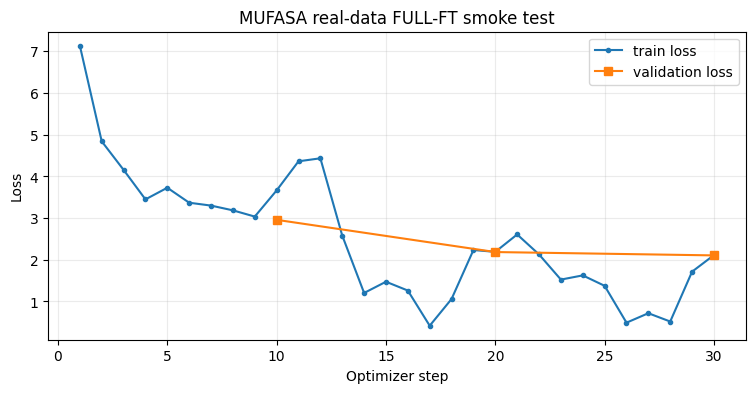

Mean first 5 train losses: 4.6618
Mean last  5 train losses: 1.1114
Change: -3.5504 (-76.2%)

✅ LOSS TREND PASSED: the real full-finetuning optimization path is learning on the smoke subset.


In [12]:
#@title 11. Plot and summarize train/eval loss
import matplotlib.pyplot as plt

history=pd.DataFrame(trainer.state.log_history)
train_log=history.dropna(subset=["loss"])[["step","loss"]].copy()
eval_log=history.dropna(subset=["eval_loss"])[["step","eval_loss"]].copy()

display(train_log)
if len(eval_log):display(eval_log)

plt.figure(figsize=(9,4))
plt.plot(train_log.step,train_log.loss,marker="o",markersize=3,label="train loss")
if len(eval_log):plt.plot(eval_log.step,eval_log.eval_loss,marker="s",label="validation loss")
plt.xlabel("Optimizer step");plt.ylabel("Loss");plt.title("MUFASA real-data FULL-FT smoke test");plt.grid(alpha=.25);plt.legend();plt.show()

k=min(5,max(1,len(train_log)//3))
first=float(train_log.loss.head(k).mean())
last=float(train_log.loss.tail(k).mean())
change=last-first
pct=(change/first*100) if first else float("nan")
print(f"Mean first {k} train losses: {first:.4f}")
print(f"Mean last  {k} train losses: {last:.4f}")
print(f"Change: {change:+.4f} ({pct:+.1f}%)")
if last<first:
    print("\n✅ LOSS TREND PASSED: the real full-finetuning optimization path is learning on the smoke subset.")
else:
    print("\n⚠️ Loss did not clearly decrease over this very short noisy run. The runtime path may still be valid; inspect the curve before changing hyperparameters.")

In [13]:
#@title 12. Final smoke-test checklist
print("""
SMOKE TEST COMPLETE

Checked:
  ✓ real MUFASA TRAIN/VAL corpus or its exact cache
  ✓ shared paper-level split
  ✓ private-test JSONs never opened
  ✓ real LFM2.5-1.2B-Thinking full-finetune load
  ✓ contextual MUFASA prompt
  ✓ <think>reasoning</think> + answer completion format
  ✓ response-only labels
  ✓ real forward/backward/optimizer steps
  ✓ validation loss calls
  ✓ training-loss trend

Intentionally NOT done:
  - DPO
  - checkpoint saving
  - GGUF export
  - Kaggle upload
  - private-test evaluation

If this run passes, use Vast for the actual full 1-epoch job.
""")


SMOKE TEST COMPLETE

Checked:
  ✓ real MUFASA TRAIN/VAL corpus or its exact cache
  ✓ shared paper-level split
  ✓ private-test JSONs never opened
  ✓ real LFM2.5-1.2B-Thinking full-finetune load
  ✓ contextual MUFASA prompt
  ✓ <think>reasoning</think> + answer completion format
  ✓ response-only labels
  ✓ real forward/backward/optimizer steps
  ✓ validation loss calls
  ✓ training-loss trend

Intentionally NOT done:
  - DPO
  - checkpoint saving
  - GGUF export
  - Kaggle upload
  - private-test evaluation

If this run passes, use Vast for the actual full 1-epoch job.

